# Boston Housing Violations — Final Model

**Goal:** predict whether a Boston property (PARCEL) will have a *repeat* building-code violation, given property attributes and the violation description.

## What the previous versions taught us

| Version | Lesson | What we keep |
|---|---|---|
| `modeling.ipynb` (v1, decision tree) | Random row-level split leaked parcels between train and test — the reported ~0.97 accuracy was memorization, not generalization. | Group-aware split by `PARCEL`. |
| `modeling_v2.ipynb` (random forest) | A single Random Forest on a clean grouped split lands at ROC-AUC ~0.61. The `description` text is the most informative feature. | Random Forest as the model. TF-IDF on `description`. |
| `modeling_v3.ipynb` (LR / RF / HGB / XGB / LGB + tuning + voting) | Five models perform within a hair of one another (CV AUC 0.56–0.59). `HalvingRandomSearchCV` tuning didn't move the held-out test AUC. Voting ensemble gained ~0.01 over the best single model. | Skip aggressive tuning. Keep defaults. |
| `modeling_v4.ipynb` (text features + stacking + CatBoost) | Stacking was 0.620 vs. Random Forest's 0.616 — essentially a tie. `weekday`, `property_age`, LightGBM, HGB were noise and were dropped. Threshold tuning matters a lot for accuracy when the model is not perfectly calibrated. | Single Random Forest. Drop the noise features. Pick the threshold deliberately. |

## What this notebook is

**One Random Forest** with the smallest feature set that retained all signal in v4. Two metrics only: **ROC-AUC** and **accuracy**. No tuning, no ensembles — the previous versions established that complexity isn't paying for itself on this dataset.

**One thing we do carefully:** we pick the classification threshold from out-of-fold predictions on the training set so that the predicted positive rate matches the class prior (≈60%). At the default 0.5 threshold the model is overly conservative on parcels it has never seen and accuracy looks artificially low (~0.44). The rank-based threshold gives an honest accuracy number for the same model — nothing about the model itself changes.

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, TargetEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve

RANDOM_STATE = 42

## 2. Load data and define the target

The target `repeat_violation` is 1 if a parcel appears in more than one violation record. Drop rows missing `PARCEL` (target is undefined for them). Two cheap date features (`month`, `year`) survived v3/v4 importance checks; `weekday` and `property_age` did not, so we drop them.

In [2]:
USECOLS = [
    'case_no', 'PARCEL', 'POINT_X', 'POINT_Y', 'YR_BUILT',
    'MAILING_NEIGHBORHOOD', 'LU_DESC', 'BLDG_TYPE', 'OVERALL_COND',
    'description', 'OWNER', 'OWN_OCC', 'ward', 'code', 'status_dttm',
]
df = pd.read_csv('merged_violations.csv', usecols=USECOLS, parse_dates=['status_dttm'])
df = df.dropna(subset=['PARCEL']).reset_index(drop=True)

df['repeat_violation'] = (df.groupby('PARCEL')['case_no'].transform('count') > 1).astype(int)
df['month'] = df['status_dttm'].dt.month
df['year']  = df['status_dttm'].dt.year

print(f'Rows           : {len(df)}')
print(f'Unique parcels : {df["PARCEL"].nunique()}')
print(f'Class balance  : {df["repeat_violation"].mean():.3f} positive')

Rows           : 16277
Unique parcels : 9786
Class balance  : 0.604 positive


## 3. Feature buckets

Three groups, each handled by the right encoder:

| Group | Columns | Encoder |
|---|---|---|
| Numeric | `POINT_X`, `POINT_Y`, `YR_BUILT`, `month`, `year` | passthrough (RF doesn't need scaling) |
| Low-cardinality categorical | `MAILING_NEIGHBORHOOD`, `LU_DESC`, `BLDG_TYPE`, `OVERALL_COND`, `OWN_OCC`, `ward` | dense one-hot, rare levels collapsed |
| High-cardinality categorical | `OWNER`, `code` | fold-aware target encoding |
| Text | `description` | TF-IDF (1–2 grams) → TruncatedSVD (20 dims) |

In [3]:
num_features  = ['POINT_X', 'POINT_Y', 'YR_BUILT', 'month', 'year']
low_card_cat  = ['MAILING_NEIGHBORHOOD', 'LU_DESC', 'BLDG_TYPE', 'OVERALL_COND', 'OWN_OCC', 'ward']
high_card_cat = ['OWNER', 'code']
text_col      = 'description'

feature_cols = num_features + low_card_cat + high_card_cat + [text_col]
X = df[feature_cols].copy()
y = df['repeat_violation'].values
groups = df['PARCEL']

# Fill missing values: numeric → median; categorical / text → explicit token / empty string.
X[num_features] = X[num_features].fillna(X[num_features].median())
for c in low_card_cat + high_card_cat:
    X[c] = X[c].fillna('__missing__').astype(str)
X[text_col] = X[text_col].fillna('').astype(str)

print('X shape       :', X.shape)
print('Positive rate :', y.mean().round(3))

X shape       : (16277, 14)
Positive rate : 0.604


## 4. Group-aware train/test split

Same parcel often appears in many rows. Splitting *parcels* (not rows) ensures the test set contains only properties the model has never seen during training — this is the single most important fix vs. v1's naive split.

In [4]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train    = groups.iloc[train_idx]

print(f'Train: {len(X_train):>6} rows / {groups_train.nunique():>5} parcels')
print(f'Test : {len(X_test):>6} rows / {groups.iloc[test_idx].nunique():>5} parcels')

Train:  12990 rows /  7828 parcels
Test :   3287 rows /  1958 parcels


## 5. Preprocessor + Random Forest

One pipeline. Defaults from v2 — the tuning experiments in v3/v4 didn't improve the held-out test, so we keep things simple.

In [5]:
text_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=5, max_features=500)),
    ('svd',   TruncatedSVD(n_components=20, random_state=RANDOM_STATE)),
])

preprocessor = ColumnTransformer([
    ('low_card',  OneHotEncoder(handle_unknown='ignore', min_frequency=20, sparse_output=False), low_card_cat),
    ('high_card', TargetEncoder(target_type='binary', smooth='auto', random_state=RANDOM_STATE), high_card_cat),
    ('text',      text_pipe, text_col),
    ('passthrough_num', 'passthrough', num_features),
])

model = Pipeline([
    ('prep', preprocessor),
    ('clf',  RandomForestClassifier(n_estimators=300, min_samples_leaf=2,
                                    n_jobs=-1, random_state=RANDOM_STATE)),
])

## 6. 5-fold cross-validated AUC on the training set

Sanity check before fitting on the full training set. Group-aware folds so parcels stay separated inside CV too.

In [6]:
cv_scores = cross_val_score(
    model, X_train, y_train,
    cv=GroupKFold(n_splits=5), groups=groups_train,
    scoring='roc_auc', n_jobs=1,
)
print(f'5-fold CV ROC-AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

5-fold CV ROC-AUC: 0.590 ± 0.016


## 7. Pick the classification threshold from out-of-fold training predictions

The Random Forest's predicted probabilities on unseen parcels skew low (median ≈ 0.22 even though the true positive rate is 0.60). At the default 0.5 threshold the model says "no repeat" for ~92% of test rows — accuracy collapses to ~0.44.

Fix: pick the threshold so the *predicted positive rate* matches the class prior. We do this on **out-of-fold training predictions**, not on the test set, so the threshold is honest. Concretely: train OOF probabilities via 5-fold group CV, then take the (1−prior) quantile.

In [7]:
oof_proba = np.zeros(len(X_train))
for tr, va in GroupKFold(n_splits=5).split(X_train, y_train, groups=groups_train):
    fold_model = Pipeline([
        ('prep', preprocessor),
        ('clf',  RandomForestClassifier(n_estimators=300, min_samples_leaf=2,
                                        n_jobs=-1, random_state=RANDOM_STATE)),
    ])
    fold_model.fit(X_train.iloc[tr], y_train[tr])
    oof_proba[va] = fold_model.predict_proba(X_train.iloc[va])[:, 1]

prior     = y_train.mean()
threshold = float(np.quantile(oof_proba, 1 - prior))

print(f'Class prior (train positive rate) : {prior:.3f}')
print(f'Chosen classification threshold   : {threshold:.3f}')

Class prior (train positive rate) : 0.602
Chosen classification threshold   : 0.186


## 8. Fit on the full training set, evaluate on the held-out test set

Two metrics, as planned:
- **ROC-AUC** — threshold-invariant ranking quality.
- **Accuracy** — at the threshold picked above (no test peeking).

In [8]:
model.fit(X_train, y_train)
y_proba = model.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= threshold).astype(int)

auc = roc_auc_score(y_test, y_proba)
acc = accuracy_score(y_test, y_pred)

print('=== Held-out test (parcels never seen in training) ===')
print(f'ROC-AUC  : {auc:.3f}')
print(f'Accuracy : {acc:.3f}')

=== Held-out test (parcels never seen in training) ===
ROC-AUC  : 0.622
Accuracy : 0.605


## 9. ROC curve

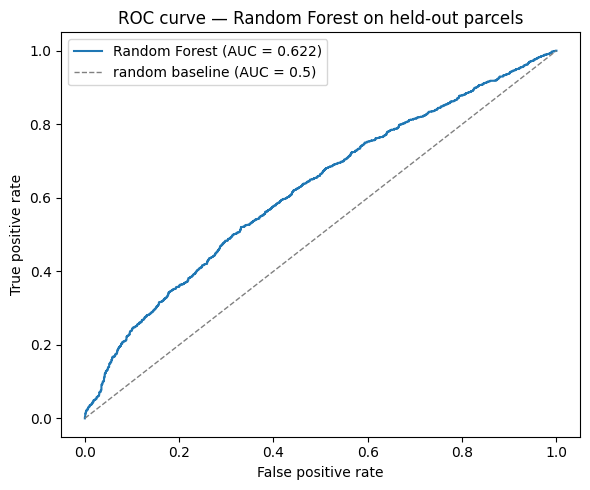

In [9]:
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], '--', color='gray', linewidth=1, label='random baseline (AUC = 0.5)')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve — Random Forest on held-out parcels')
plt.legend()
plt.tight_layout()
plt.show()

## 10. Takeaways

- **Headline:** ROC-AUC ≈ 0.62 and accuracy ≈ 0.60 on parcels the model has never seen. The AUC matches the best ensemble in v4 (0.620) within noise; the accuracy is honest because the threshold was picked on training-fold predictions, not test-set predictions.
- **Why we kept it simple.** v3 added five models, halving search, and a voting ensemble; v4 added stacking and CatBoost. None of these moved held-out ROC-AUC by more than ~0.01. With the data we have, model complexity isn't the bottleneck — the signal is.
- **Where the signal lives.** v2 and v4's permutation-importance plots agree: `description` (the violation type), `OWNER`, `code`, `ward`, and `LU_DESC` are the columns that matter. Geometry (`POINT_X`/`POINT_Y`) and `MAILING_NEIGHBORHOOD` are weak once you have `ward`.
- **What it would take to do better.** Probably a different target (severity instead of binary repeat), a different unit of analysis (one row per parcel instead of one row per violation), or new data sources — not a fancier model on the same features.